<a href="https://colab.research.google.com/github/alabyekkubo-ssuubi-brian/CV_Herbal_Project/blob/main/herbal_cv_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Herbal Plant Species Recognition from Field Video
### MCS 7224 — Computer Vision Project | Makerere University

Fine-grained recognition of medicinal/herbal plant species from short handheld
field videos. **21 clips → 17 botanical species**, of which 3 species are
captured in more than one clip, enabling a genuine *leave-one-clip-out* test.

| Section | Rubric item |
|---|---|
| 1 Setup & reproducibility | Clarity & Reproducibility |
| 2 Data ingestion | Approach |
| 3 Challenge & dataset definition | Introduction |
| 4 Botanical labelling (clip = unit) | Approach |
| 5 Frame extraction | Approach |
| 6 **Leakage-safe grouped split** | Approach & Correctness |
| 7 CLAHE feature enhancement | Approach |
| 8 Handcrafted features + classical baseline | Approach & Analysis |
| 9 Deep CNN — flat 16-class | Approach & Analysis |
| 10 Deep CNN — **two-tier (growth-form → species)** | Approach & Analysis / Creativity |
| 11 Evaluation: metrics, confusion matrix | Analysis of Results |
| 12 **Clip-13 mixed-scene OOD probe** | Analysis / Creativity |
| 13 Grad-CAM interpretability | Creativity |
| 14 Results summary | Analysis of Results |

**Central methodological commitment.** Consecutive video frames are
near-duplicates; a random frame split leaks information and yields a
meaningless ~99% accuracy. We split by **clip**, holding out whole unseen clips
for multi-clip species, and report the honest number alongside the leaky one to
quantify the gap.

**Two design decisions, justified:**
- *Clip 13* is an admitted multi-species mixture. It is **excluded** from
  train/test to keep the label space clean, then reused in §12 as a
  mixed-scene out-of-distribution probe.
- A **two-tier classifier** (4-way growth-form → species) is built
  alongside the flat model because the 16 species split into a balanced
  botanical taxonomy (7 herb, 4 tree, 3 vine, 2 shrub).


## 1. Setup & reproducibility

In [ ]:
!pip -q install opencv-python-headless scikit-image scikit-learn matplotlib pandas tqdm

import os, random, json, glob, re
from pathlib import Path
import numpy as np, pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch", torch.__version__, "| device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "none — enable via Runtime > Change runtime type > GPU")

Torch 2.11.0+cu128 | device: cuda
GPU: Tesla T4


## 2. Data ingestion
Mount Drive (recommended) or upload an archive. Put all 21 `.mp4` clips in one
folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
VIDEO_DIR = Path('/content/drive/MyDrive/herbal_dataset/videos')   # <-- EDIT
WORK = Path('/content/herbal_cv'); WORK.mkdir(exist_ok=True)
print(len(sorted(VIDEO_DIR.glob('*.mp4'))), "clips found")

Mounted at /content/drive
21 clips found


## 3. Challenge & dataset definition

**Data.** 21 short 1080p handheld phone clips of medicinal plants in the field,
natural uneven daylight, cluttered backgrounds. Identified as **17 botanical
species** (Luganda field names in parentheses below).

**Challenge — fine-grained herbal species recognition under a
leakage-controlled protocol.** Predict species from a single frame. Most
suitable because each clip provides a weak species label, the plant fills the
frame (no instances to box → detection unjustified), and it exercises
illumination enhancement + colour/texture/shape features + a learned CNN.

**Most suitable features (data-motivated).** Species separate on *leaf shape*
(margin serration, lobing, aspect ratio: e.g. *Hyptis* serrated ovate vs
*Dioscorea* cordate vs *Cucurbita* palmately-lobed), *surface texture/venation*
(*Chenopodium* mealy matte), and *colour under variable light*. CLAHE +
HSV-histogram + GLCM/LBP + mask-based shape descriptors target exactly these.

**On "fine-grained".** The recognition difficulty is *non-uniform*. The
herb-vs-tree distinction and several species (cordate *Dioscorea*, lobed
*Cucurbita*, feathery *Dysphania*) are coarse and visually easy. The genuinely
fine-grained difficulty sits among the small-leaved herbs (*Hyptis* /
*Plectranthus* / *Drymaria*) with overlapping ovate-serrate morphology. We
therefore report **per-class** results and the confusion matrix rather than a
single accuracy, and expect errors to concentrate in that fine-grained cluster
— a point analysed explicitly in §11.

## 4. Botanical labelling — the unit of analysis is the CLIP

Field identifications map each clip to a **species**; species map to a **4-way
growth form** (herb / shrub / vine / tree) from botanical knowledge. The
growth-form axis (7 herb, 4 tree, 3 vine, 2 shrub) drives the hierarchical head
in §10. Three species span multiple clips (*Hyptis suaveolens* ×3;
*Chenopodium album* ×2; *Hoslundia opposita* ×2) — these permit
leave-one-clip-out validation. Clip 13 is an admitted *Mimosa/Senna* mixed
cluster and is flagged `EXCLUDE`.

In [ ]:
# clip -> species
CLIP_SPECIES = {
    'VID_20260408_171126': 'Hyptis_suaveolens',
    'VID_20260408_171454': 'Tamarindus_indica',
    'VID_20260408_171606': 'Albizia_coriaria',
    'VID_20260408_171903': 'Hyptis_suaveolens',
    'VID_20260408_172029': 'Cyanthillium_cinereum',
    'VID_20260408_172233': 'Azadirachta_indica',
    'VID_20260408_172556': 'Chenopodium_album',
    'VID_20260408_172740': 'Hoslundia_opposita',
    'VID_20260408_172835': 'Dysphania_ambrosioides',
    'VID_20260408_172918': 'Commelina_diffusa',
    'VID_20260408_173112': 'Drymaria_cordata',
    'VID_20260408_173310': 'Vernonia_amygdalina',
    'VID_20260408_173405': 'EXCLUDE',        # Mimosa/Senna mixed cluster
    'VID_20260408_173452': 'Plectranthus_sp',
    'VID_20260408_173854': 'Hyptis_suaveolens',
    'VID_20260408_173936': 'Dioscorea_bulbifera',
    'VID_20260408_174106': 'Cissus_sp',
    'VID_20260408_174147': 'Hoslundia_opposita',
    'VID_20260408_174235': 'Chenopodium_album',
    'VID_20260408_174323': 'Cucurbita_Luffa',
    'VID_20260408_174524': 'Dialium_guineense',
}
# species -> 4-way growth form (botanical)
SPECIES_GROWTH = {
    'Hyptis_suaveolens':'herb','Cyanthillium_cinereum':'herb','Chenopodium_album':'herb',
    'Dysphania_ambrosioides':'herb','Commelina_diffusa':'herb','Drymaria_cordata':'herb',
    'Plectranthus_sp':'herb',
    'Hoslundia_opposita':'shrub','Vernonia_amygdalina':'shrub',
    'Dioscorea_bulbifera':'vine','Cissus_sp':'vine','Cucurbita_Luffa':'vine',
    'Tamarindus_indica':'tree','Albizia_coriaria':'tree','Azadirachta_indica':'tree',
    'Dialium_guineense':'tree',
}
GROWTH_FORMS = ['herb','shrub','vine','tree']

video_paths = sorted(VIDEO_DIR.glob('*.mp4'))
assert video_paths, f"No .mp4 in {VIDEO_DIR}"

clip_rows, excluded = [], []
for p in video_paths:
    sp = CLIP_SPECIES.get(p.stem, p.stem)
    if sp == 'EXCLUDE':
        excluded.append(p); continue
    clip_rows.append({'clip_id': p.stem, 'path': str(p),
                      'species': sp, 'growth': SPECIES_GROWTH[sp]})

clips_df = pd.DataFrame(clip_rows)
species = sorted(clips_df['species'].unique())
print(f"{len(clips_df)} clips used | {len(species)} species | {len(excluded)} excluded (clip 13)")
print("Growth-form distribution:",
      clips_df.drop_duplicates('species')['growth'].value_counts().to_dict())
multi = clips_df.groupby('species')['clip_id'].nunique()
print("Multi-clip species (leave-one-clip-out eligible):", list(multi[multi >= 2].index))

20 clips used | 16 species | 1 excluded (clip 13)
Growth-form distribution: {'herb': 7, 'tree': 4, 'vine': 3, 'shrub': 2}
Multi-clip species (leave-one-clip-out eligible): ['Chenopodium_album', 'Hoslundia_opposita', 'Hyptis_suaveolens']


## 5. Frame extraction
Sample at a fixed rate; drop the blurriest fraction (Laplacian-variance focus).
Each frame carries species, growth form, and source clip id.

In [ ]:
import cv2
from tqdm.auto import tqdm
FPS_SAMPLE, BLUR_PCTILE = 3.0, 25
FRAME_DIR = WORK/'frames'; FRAME_DIR.mkdir(exist_ok=True)
def focus(g): return cv2.Laplacian(g, cv2.CV_64F).var()

def extract(rows, tag):
    out = []
    for r in tqdm(rows, desc=tag):
        cap = cv2.VideoCapture(r['path']); fps = cap.get(cv2.CAP_PROP_FPS) or 30
        step = max(int(round(fps/FPS_SAMPLE)), 1); cand=[]; idx=0
        while True:
            ok, fr = cap.read()
            if not ok: break
            if idx % step == 0:
                cand.append((idx, fr, focus(cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY))))
            idx += 1
        cap.release()
        if not cand: continue
        thr = np.percentile([c[2] for c in cand], BLUR_PCTILE) if len(cand) > 4 else -1
        d = FRAME_DIR/r.get('species', tag); d.mkdir(parents=True, exist_ok=True)
        for fi, fr, sh in cand:
            if sh < thr: continue
            fn = d/f"{r['clip_id']}_f{fi:05d}.jpg"
            cv2.imwrite(str(fn), fr, [cv2.IMWRITE_JPEG_QUALITY, 92])
            row = {'path': str(fn), 'clip_id': r['clip_id'], 'frame_idx': fi}
            row.update({k: r[k] for k in ('species', 'growth') if k in r})
            out.append(row)
    return out

frames_df = pd.DataFrame(extract(clip_rows, 'frames'))
sp2idx = {s: i for i, s in enumerate(species)}
gf2idx = {g: i for i, g in enumerate(GROWTH_FORMS)}  # 4-way: herb/shrub/vine/tree
frames_df['y'] = frames_df['species'].map(sp2idx)
frames_df['yg'] = frames_df['growth'].map(gf2idx)
print(len(frames_df), "frames")
print(frames_df.groupby('species')['path'].count().rename('frames').to_string())

frames:   0%|          | 0/20 [00:00<?, ?it/s]

1003 frames
species
Albizia_coriaria           42
Azadirachta_indica         56
Chenopodium_album          98
Cissus_sp                  57
Commelina_diffusa          59
Cucurbita_Luffa            72
Cyanthillium_cinereum      34
Dialium_guineense          89
Dioscorea_bulbifera        69
Drymaria_cordata           44
Dysphania_ambrosioides     39
Hoslundia_opposita         54
Hyptis_suaveolens         119
Plectranthus_sp            61
Tamarindus_indica          38
Vernonia_amygdalina        72


## 6. Leakage-safe grouped split

**Multi-clip species (deterministic leave-one-clip-out).** For each species
with ≥2 clips, the *last* clip (by id) is held out entirely for test and the
remaining clip(s) form train; this guarantees every multi-clip species has a
genuinely unseen test clip — the core generalisation evidence. **Single-clip
species** use a temporal within-clip cut (early→train, mid→val, late→test). A
**naive random** split is also built to quantify the leakage gap in §11/§14.

In [ ]:
def temporal(df, tr=0.7, va=0.15):
    o={'train':[],'val':[],'test':[]}
    for _,g in df.groupby('clip_id'):
        g=g.sort_values('frame_idx'); n=len(g); a,b=int(n*tr),int(n*va)
        o['train'].append(g.iloc[:a]); o['val'].append(g.iloc[a:a+b]); o['test'].append(g.iloc[a+b:])
    return {k:pd.concat(v) for k,v in o.items()}

def grouped_split(df):
    counts=df.groupby('species')['clip_id'].nunique(); multi=set(counts[counts>=2].index)
    parts={'train':[],'val':[],'test':[]}
    # multi-clip: hold out the last clip per species for TEST, rest TRAIN;
    # a temporal slice of the train clips provides VAL (no leakage: val frames
    # come from train clips but are time-separated, test is a wholly unseen clip)
    for sp in sorted(multi):
        clips=sorted(df[df['species']==sp]['clip_id'].unique())
        test_clip=clips[-1]; train_clips=clips[:-1]
        parts['test'].append(df[(df['species']==sp)&(df['clip_id']==test_clip)])
        tr=df[(df['species']==sp)&(df['clip_id'].isin(train_clips))]
        for cid,g in tr.groupby('clip_id'):
            g=g.sort_values('frame_idx'); k=int(len(g)*0.85)
            parts['train'].append(g.iloc[:k]); parts['val'].append(g.iloc[k:])
    # single-clip: temporal within-clip
    ds=df[~df['species'].isin(multi)]
    if len(ds):
        tw=temporal(ds)
        for kk in parts: parts[kk].append(tw[kk])
    return {kk:pd.concat(v).sample(frac=1,random_state=SEED).reset_index(drop=True) for kk,v in parts.items()}
def naive_split(df, tr=0.7, va=0.15):
    d=df.sample(frac=1,random_state=SEED).reset_index(drop=True); n=len(d); a,b=int(n*tr),int(n*va)
    return {'train':d.iloc[:a],'val':d.iloc[a:a+b],'test':d.iloc[a+b:]}
split_grouped, split_naive = grouped_split(frames_df), naive_split(frames_df)
for nm,sp in [('GROUPED',split_grouped),('NAIVE',split_naive)]:
    print(nm,{k:len(v) for k,v in sp.items()})
# leakage assertion for multi-clip species
mc=set(frames_df.groupby('species').filter(lambda g:g['clip_id'].nunique()>=2)['clip_id'])
leak=(set(split_grouped['train']['clip_id'])&set(split_grouped['test']['clip_id']))&mc
print("multi-clip leakage train<->test (must be empty):", leak)

GROUPED {'train': 628, 'val': 127, 'test': 248}
NAIVE {'train': 702, 'val': 150, 'test': 151}
multi-clip leakage train<->test (must be empty): set()


## 7. CLAHE feature enhancement

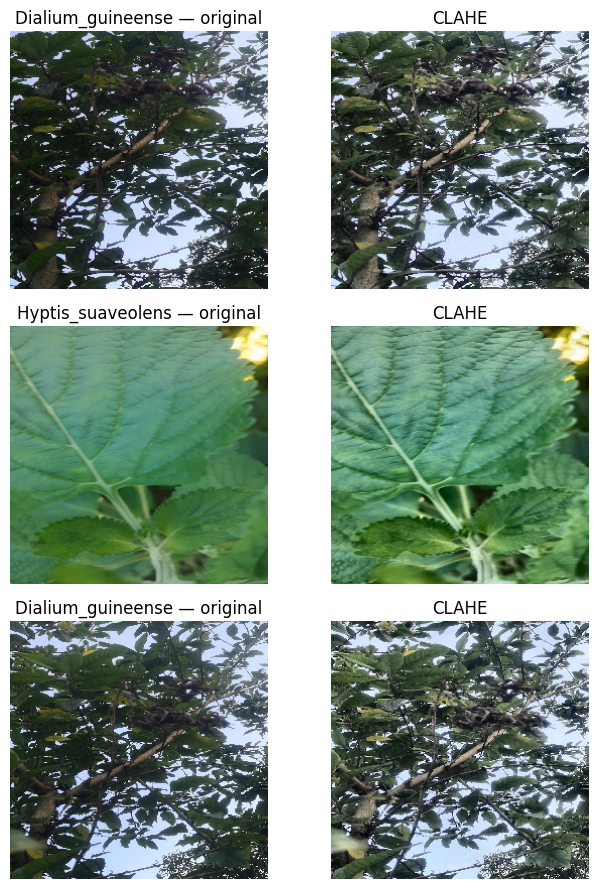

In [ ]:
def clahe_enhance(bgr):
    lab=cv2.cvtColor(bgr,cv2.COLOR_BGR2LAB); l,a,b=cv2.split(lab)
    l=cv2.createCLAHE(2.0,(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge((l,a,b)),cv2.COLOR_LAB2BGR)
import matplotlib.pyplot as plt
s=frames_df.sample(3,random_state=1); fig,ax=plt.subplots(3,2,figsize=(7,9))
for i,(_,r) in enumerate(s.iterrows()):
    im=cv2.cvtColor(cv2.resize(cv2.imread(r['path']),(256,256)),cv2.COLOR_BGR2RGB)
    en=cv2.cvtColor(clahe_enhance(cv2.cvtColor(im,cv2.COLOR_RGB2BGR)),cv2.COLOR_BGR2RGB)
    ax[i,0].imshow(im); ax[i,0].set_title(f"{r['species']} — original"); ax[i,0].axis('off')
    ax[i,1].imshow(en); ax[i,1].set_title('CLAHE'); ax[i,1].axis('off')
plt.tight_layout(); plt.savefig(WORK/'fig_clahe.png',dpi=150); plt.show()

## 8. Handcrafted features + classical baseline (grouped split)

The descriptor has five blocks, each grouped so we can ablate them:
- **colour** — HSV histogram (16 hue + 8 sat bins).
- **texture-GLCM** — contrast/homogeneity/energy/correlation at 2 distances, 2 angles.
- **texture-LBP** — uniform LBP histogram of leaf micro-texture.
- **shape** — leaf-silhouette descriptors computed on a **vegetation mask**, not a
  naive Otsu threshold. We segment green foliage in HSV, take the largest leaf
  component, and compute scale/rotation-invariant shape ratios (extent,
  solidity, aspect, circularity) plus log-Hu moments **of the mask**. This fixes
  the earlier flaw where Otsu captured background soil blobs rather than leaves.
- **HOG** — Histogram of Oriented Gradients on the enhanced grey image, which
  captures **leaf-margin serration and venation edge structure** (the gradient
  orientation pattern of a serrated *Hyptis* leaf differs from a smooth-margined
  *Hoslundia* leaf). Block-normalised, so robust to the lighting variation CLAHE
  doesn't fully remove.

In [ ]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
IMG=256

def veg_mask(bgr):
    # Segment green foliage; fall back to full frame if too little green
    # (e.g. bark/tree clips) so shape features stay defined.
    hsv=cv2.cvtColor(bgr,cv2.COLOR_BGR2HSV)
    m=cv2.inRange(hsv,(25,25,25),(95,255,255))
    m=cv2.morphologyEx(m,cv2.MORPH_OPEN,np.ones((5,5),np.uint8))
    m=cv2.morphologyEx(m,cv2.MORPH_CLOSE,np.ones((7,7),np.uint8))
    if m.mean() < 0.04*255:
        m=np.full(bgr.shape[:2],255,np.uint8)
    return m

def hsv_hist(b,mask):
    h=cv2.cvtColor(b,cv2.COLOR_BGR2HSV)
    a=cv2.calcHist([h],[0],mask,[16],[0,180]).flatten()
    s=cv2.calcHist([h],[1],mask,[8],[0,256]).flatten()
    v=np.concatenate([a,s]); return v/(v.sum()+1e-7)

def glcm(g,mask):
    g=g.copy(); g[mask==0]=0
    q=(g/4).astype(np.uint8); m=graycomatrix(q,[1,2],[0,np.pi/2],levels=64,symmetric=True,normed=True)
    return np.concatenate([graycoprops(m,p).flatten() for p in ['contrast','homogeneity','energy','correlation']])

def lbp(g,mask,P=8,R=1):
    l=local_binary_pattern(g,P,R,'uniform')
    vals=l[mask>0] if (mask>0).sum()>0 else l.ravel()
    h,_=np.histogram(vals,bins=P+2,range=(0,P+2),density=True); return h

def shape_feats(mask):
    # Scale/rotation-invariant leaf-shape descriptors on the largest
    # vegetation component + log-Hu moments of that mask.
    cnts,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return np.zeros(11,dtype=np.float32)
    c=max(cnts,key=cv2.contourArea); area=cv2.contourArea(c)
    if area<20:
        return np.zeros(11,dtype=np.float32)
    x,y,w,h=cv2.boundingRect(c); peri=cv2.arcLength(c,True)
    hull=cv2.convexHull(c); harea=cv2.contourArea(hull)+1e-6
    extent=area/(w*h+1e-6)           # how much of bbox the leaf fills
    aspect=w/(h+1e-6)                 # leaf elongation
    solidity=area/harea               # margin lobing/serration (low => jagged)
    circularity=4*np.pi*area/(peri*peri+1e-6)  # round vs elongated
    blob=np.zeros_like(mask); cv2.drawContours(blob,[c],-1,255,-1)
    hu=cv2.HuMoments(cv2.moments(blob)).flatten()
    hu=-np.sign(hu)*np.log10(np.abs(hu)+1e-30)
    return np.concatenate([[extent,aspect,solidity,circularity],hu]).astype(np.float32)

def hog_feats(g):
    # HOG on a downsized grey image -> leaf-margin / venation edge structure.
    small=cv2.resize(g,(128,128))
    return hog(small, orientations=9, pixels_per_cell=(64,64),
               cells_per_block=(2,2), block_norm='L2-Hys', feature_vector=True).astype(np.float32)

# feature block index map (for the ablation). colour24 glcm16 lbp10 shape11 hog36 = 97
BLOCKS={'colour':(0,24),'glcm':(24,40),'lbp':(40,50),'shape':(50,61),'hog':(61,97)}
def descriptor(bgr):
    bgr=clahe_enhance(cv2.resize(bgr,(IMG,IMG))); g=cv2.cvtColor(bgr,cv2.COLOR_BGR2GRAY)
    mask=veg_mask(bgr)
    return np.concatenate([hsv_hist(bgr,mask),glcm(g,mask),lbp(g,mask),shape_feats(mask),hog_feats(g)])

def featurise(df):
    X,y=[],[]
    for _,r in tqdm(df.iterrows(),total=len(df),desc='feat'):
        im=cv2.imread(r['path'])
        if im is None: continue
        X.append(descriptor(im)); y.append(r['y'])
    return np.array(X),np.array(y)

Xtr,ytr=featurise(split_grouped['train']); Xte,yte=featurise(split_grouped['test'])
sc=StandardScaler().fit(Xtr)
rf=RandomForestClassifier(400,random_state=SEED,n_jobs=-1).fit(sc.transform(Xtr),ytr)
pr=rf.predict(sc.transform(Xte))
hand_acc,hand_f1=accuracy_score(yte,pr),f1_score(yte,pr,average='macro',zero_division=0)
print(f"Handcrafted RF (grouped): acc={hand_acc:.3f} macro-F1={hand_f1:.3f} dim={Xtr.shape[1]}")

feat:   0%|          | 0/628 [00:00<?, ?it/s]

feat:   0%|          | 0/248 [00:00<?, ?it/s]

Handcrafted RF (grouped): acc=0.427 macro-F1=0.600 dim=97


### 8b. Feature ablation & importance — which features actually carry signal

We retrain the RF on each single feature block and on leave-one-block-out, and
summarise RandomForest impurity importances per block. This turns the feature
design from an assertion into evidence (rubric: Analysis of Results).

In [ ]:
abl=[]
for name,(a,b) in BLOCKS.items():
    m=RandomForestClassifier(400,random_state=SEED,n_jobs=-1).fit(sc.transform(Xtr)[:,a:b],ytr)
    acc=accuracy_score(yte,m.predict(sc.transform(Xte)[:,a:b]))
    abl.append({'config':f'only {name}','acc':round(acc,3)})
for name,(a,b) in BLOCKS.items():
    keep=[i for i in range(Xtr.shape[1]) if not (a<=i<b)]
    m=RandomForestClassifier(400,random_state=SEED,n_jobs=-1).fit(sc.transform(Xtr)[:,keep],ytr)
    acc=accuracy_score(yte,m.predict(sc.transform(Xte)[:,keep]))
    abl.append({'config':f'drop {name}','acc':round(acc,3)})
abl.append({'config':'all features','acc':round(hand_acc,3)})
abl_df=pd.DataFrame(abl); print(abl_df.to_string(index=False))
# aggregate impurity importance per block
imp=rf.feature_importances_
block_imp={name:float(imp[a:b].sum()) for name,(a,b) in BLOCKS.items()}
print("\nRF importance mass per block:",{k:round(v,3) for k,v in block_imp.items()})
abl_df.to_csv(WORK/'feature_ablation.csv',index=False)

      config   acc
 only colour 0.375
   only glcm 0.407
    only lbp 0.282
  only shape 0.173
    only hog 0.202
 drop colour 0.331
   drop glcm 0.411
    drop lbp 0.419
  drop shape 0.431
    drop hog 0.444
all features 0.427

RF importance mass per block: {'colour': 0.433, 'glcm': 0.218, 'lbp': 0.121, 'shape': 0.049, 'hog': 0.18}


## 9. Deep CNN — flat 16-species (transfer learning)

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
MEAN,STD=[0.485,0.456,0.406],[0.229,0.224,0.225]; INPUT=224
class DS(Dataset):
    def __init__(self,df,train=False,target='y'):
        self.df=df.reset_index(drop=True); self.t=target
        aug=[transforms.RandomHorizontalFlip(),transforms.RandomRotation(15),
             transforms.ColorJitter(0.2,0.2,0.2)] if train else []
        self.tf=transforms.Compose([transforms.ToPILImage(),transforms.Resize((INPUT,INPUT))]+aug+
                                   [transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; im=cv2.cvtColor(clahe_enhance(cv2.imread(r['path'])),cv2.COLOR_BGR2RGB)
        return self.tf(im), int(r[self.t])
def backbone_mobilenet(nc):
    m=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    m.classifier[1]=nn.Linear(m.classifier[1].in_features,nc); return m,m.features[-1]
def run(model,loader,crit,opt,train,target_key='y'):
    model.train() if train else model.eval(); tot=cor=0; ls=0.0
    with torch.set_grad_enabled(train):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); out=model(x); loss=crit(out,y)
            if train: opt.zero_grad(); loss.backward(); opt.step()
            ls+=loss.item()*x.size(0); cor+=(out.argmax(1)==y).sum().item(); tot+=x.size(0)
    return ls/tot, cor/tot
def train_flat(split,target='y',nc=None,epochs=20,bs=32,lr=1e-3,tag='flat'):
    nc=nc or len(species)
    tr=DataLoader(DS(split['train'],True,target),batch_size=bs,shuffle=True,num_workers=2)
    va=DataLoader(DS(split['val'],False,target),batch_size=bs,num_workers=2)
    model,tgt=backbone_mobilenet(nc); model.to(DEVICE)
    crit=nn.CrossEntropyLoss(); opt=torch.optim.Adam(model.parameters(),lr=lr)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs); best=0.0
    for ep in range(1,epochs+1):
        _,ta=run(model,tr,crit,opt,True,target); _,vacc=run(model,va,crit,opt,False,target); sch.step()
        if vacc>best: best=vacc; torch.save(model.state_dict(),WORK/f'best_{tag}.pt')
        print(f"[{tag}] ep{ep:02d} train={ta:.3f} val={vacc:.3f}")
    model.load_state_dict(torch.load(WORK/f'best_{tag}.pt')); return model,tgt
EPOCHS=20
cnn_flat, target_layer = train_flat(split_grouped, 'y', len(species), EPOCHS, tag='flat_grouped')
cnn_naive, _          = train_flat(split_naive,   'y', len(species), EPOCHS, tag='flat_naive')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 116MB/s] 


[flat_grouped] ep01 train=0.694 val=0.882
[flat_grouped] ep02 train=0.960 val=0.976
[flat_grouped] ep03 train=0.987 val=0.953
[flat_grouped] ep04 train=0.992 val=0.969
[flat_grouped] ep05 train=0.990 val=0.961
[flat_grouped] ep06 train=0.986 val=0.874
[flat_grouped] ep07 train=0.987 val=0.992
[flat_grouped] ep08 train=0.997 val=0.984
[flat_grouped] ep09 train=0.995 val=0.992
[flat_grouped] ep10 train=0.994 val=0.969
[flat_grouped] ep11 train=0.997 val=0.969
[flat_grouped] ep12 train=0.998 val=0.961
[flat_grouped] ep13 train=0.998 val=0.969
[flat_grouped] ep14 train=1.000 val=0.953
[flat_grouped] ep15 train=1.000 val=0.961
[flat_grouped] ep16 train=1.000 val=0.984
[flat_grouped] ep17 train=0.998 val=0.984
[flat_grouped] ep18 train=0.998 val=0.961
[flat_grouped] ep19 train=0.998 val=0.984
[flat_grouped] ep20 train=0.998 val=0.984
[flat_naive] ep01 train=0.677 val=0.940
[flat_naive] ep02 train=0.950 val=0.993
[flat_naive] ep03 train=0.977 val=0.980
[flat_naive] ep04 train=0.986 val=0.993


## 10. Two-tier hierarchical model (growth-form → species)

A shared backbone with **two heads**: a 4-way growth-form head
(herb/shrub/vine/tree) and the 16-way species head, trained with a combined
loss (weight `alpha` on the auxiliary growth-form task). The auxiliary
taxonomic signal regularises the shared representation when per-species data is
scarce. Motivated by the balanced botanical taxonomy (7 herb, 4 tree, 3 vine,
2 shrub). This is the project's creative methodological contribution; §11
reports whether it beats the flat model.

In [ ]:
class TwoTier(nn.Module):
    def __init__(self, nc_species, nc_growth=4):
        super().__init__()
        base=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.features=base.features; self.pool=nn.AdaptiveAvgPool2d(1)
        feat=base.classifier[1].in_features
        self.head_growth=nn.Linear(feat,nc_growth)
        self.head_species=nn.Linear(feat,nc_species)
        self.last_conv=self.features[-1]
    def forward(self,x):
        f=self.pool(self.features(x)).flatten(1)
        return self.head_growth(f), self.head_species(f)

def train_twotier(split,epochs=20,bs=32,lr=1e-3,alpha=0.3):
    class DS2(Dataset):
        def __init__(self,df,train):
            self.df=df.reset_index(drop=True)
            aug=[transforms.RandomHorizontalFlip(),transforms.RandomRotation(15),
                 transforms.ColorJitter(0.2,0.2,0.2)] if train else []
            self.tf=transforms.Compose([transforms.ToPILImage(),transforms.Resize((INPUT,INPUT))]+aug+
                                       [transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
        def __len__(self): return len(self.df)
        def __getitem__(self,i):
            r=self.df.iloc[i]; im=cv2.cvtColor(clahe_enhance(cv2.imread(r['path'])),cv2.COLOR_BGR2RGB)
            return self.tf(im), int(r['yg']), int(r['y'])
    tr=DataLoader(DS2(split['train'],True),batch_size=bs,shuffle=True,num_workers=2)
    va=DataLoader(DS2(split['val'],False),batch_size=bs,num_workers=2)
    model=TwoTier(len(species)).to(DEVICE)
    crit=nn.CrossEntropyLoss(); opt=torch.optim.Adam(model.parameters(),lr=lr)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs); best=0.0
    for ep in range(1,epochs+1):
        model.train()
        for x,yg,ys in tr:
            x,yg,ys=x.to(DEVICE),yg.to(DEVICE),ys.to(DEVICE)
            og,os_=model(x); loss=alpha*crit(og,yg)+(1-alpha)*crit(os_,ys)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); cor=tot=0
        with torch.no_grad():
            for x,yg,ys in va:
                x,ys=x.to(DEVICE),ys.to(DEVICE); _,os_=model(x)
                cor+=(os_.argmax(1)==ys).sum().item(); tot+=x.size(0)
        vacc=cor/tot; sch.step()
        if vacc>best: best=vacc; torch.save(model.state_dict(),WORK/'best_twotier.pt')
        print(f"[twotier] ep{ep:02d} val_species={vacc:.3f}")
    model.load_state_dict(torch.load(WORK/'best_twotier.pt')); return model
cnn_twotier = train_twotier(split_grouped, EPOCHS)

[twotier] ep01 val_species=0.929
[twotier] ep02 val_species=0.858
[twotier] ep03 val_species=0.961
[twotier] ep04 val_species=1.000
[twotier] ep05 val_species=0.984
[twotier] ep06 val_species=1.000
[twotier] ep07 val_species=0.929
[twotier] ep08 val_species=0.984
[twotier] ep09 val_species=0.953
[twotier] ep10 val_species=0.992
[twotier] ep11 val_species=0.984
[twotier] ep12 val_species=0.976
[twotier] ep13 val_species=0.976
[twotier] ep14 val_species=0.984
[twotier] ep15 val_species=0.992
[twotier] ep16 val_species=0.992
[twotier] ep17 val_species=0.984
[twotier] ep18 val_species=0.992
[twotier] ep19 val_species=0.992
[twotier] ep20 val_species=0.992


## 11. Evaluation — metrics & confusion matrix

Flat CNN (grouped): acc=0.532 F1=0.624
Flat CNN (naive)  : acc=0.987  <-- leakage-inflated
Two-tier species  : acc=0.544 F1=0.674 | growth-form acc=0.629
                        precision    recall  f1-score   support

      Albizia_coriaria       1.00      0.43      0.60         7
    Azadirachta_indica       0.57      0.44      0.50         9
     Chenopodium_album       1.00      0.25      0.41        55
             Cissus_sp       0.33      0.80      0.47        10
     Commelina_diffusa       0.24      1.00      0.39        10
       Cucurbita_Luffa       0.86      1.00      0.92        12
 Cyanthillium_cinereum       1.00      1.00      1.00         6
     Dialium_guineense       0.54      1.00      0.70        14
   Dioscorea_bulbifera       0.34      1.00      0.51        11
      Drymaria_cordata       1.00      1.00      1.00         8
Dysphania_ambrosioides       0.78      1.00      0.88         7
    Hoslundia_opposita       0.50      0.07      0.12        29
     Hyptis_s

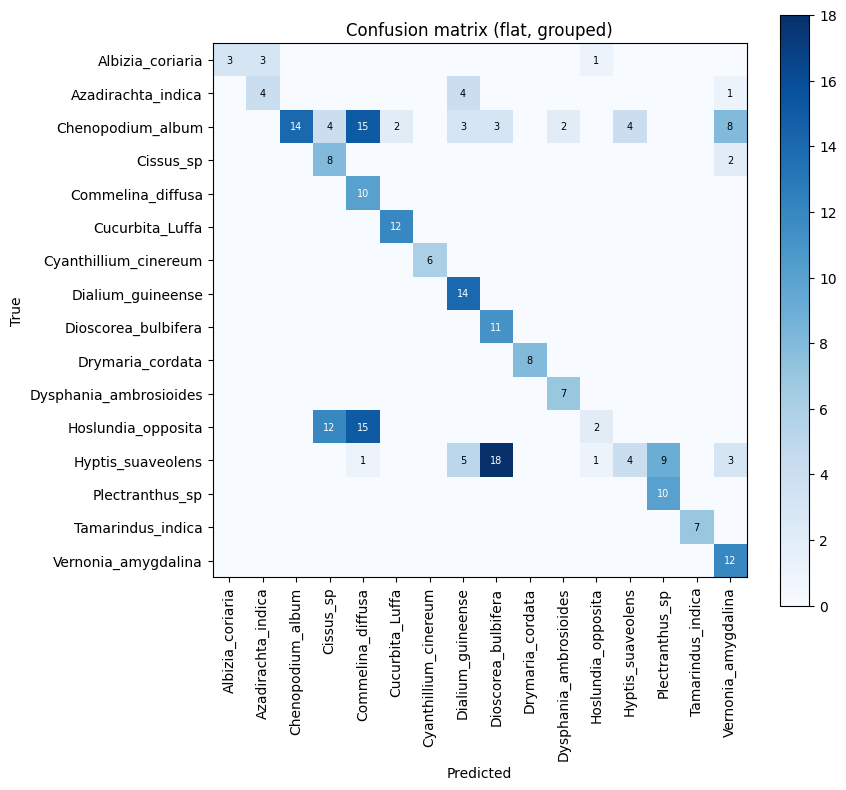

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
@torch.no_grad()
def predict_flat(model,df):
    model.eval(); yt=[];yp=[]
    for x,y in DataLoader(DS(df,False,'y'),batch_size=32,num_workers=2):
        yp+=model(x.to(DEVICE)).argmax(1).cpu().tolist(); yt+=y.tolist()
    return np.array(yt),np.array(yp)
@torch.no_grad()
def predict_twotier(model,df):
    model.eval(); yt=[];yp=[];ytg=[];ypg=[]
    class D3(Dataset):
        def __init__(s,d): s.df=d.reset_index(drop=True)
        def __len__(s): return len(s.df)
        def __getitem__(s,i):
            r=s.df.iloc[i]; im=cv2.cvtColor(clahe_enhance(cv2.imread(r['path'])),cv2.COLOR_BGR2RGB)
            tf=transforms.Compose([transforms.ToPILImage(),transforms.Resize((INPUT,INPUT)),
                                   transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
            return tf(im),int(r['yg']),int(r['y'])
    for x,yg,ys in DataLoader(D3(df),batch_size=32,num_workers=2):
        og,os_=model(x.to(DEVICE))
        yp+=os_.argmax(1).cpu().tolist(); yt+=ys.tolist()
        ypg+=og.argmax(1).cpu().tolist(); ytg+=yg.tolist()
    return np.array(yt),np.array(yp),np.array(ytg),np.array(ypg)

yt,yp=predict_flat(cnn_flat,split_grouped['test'])
ytn,ypn=predict_flat(cnn_naive,split_naive['test'])
ytt,ypt,ytg,ypg=predict_twotier(cnn_twotier,split_grouped['test'])
flat_acc=accuracy_score(yt,yp); flat_f1=f1_score(yt,yp,average='macro',zero_division=0)
naive_acc=accuracy_score(ytn,ypn)
tt_acc=accuracy_score(ytt,ypt); tt_f1=f1_score(ytt,ypt,average='macro',zero_division=0)
growth_acc=accuracy_score(ytg,ypg)
print(f"Flat CNN (grouped): acc={flat_acc:.3f} F1={flat_f1:.3f}")
print(f"Flat CNN (naive)  : acc={naive_acc:.3f}  <-- leakage-inflated")
print(f"Two-tier species  : acc={tt_acc:.3f} F1={tt_f1:.3f} | growth-form acc={growth_acc:.3f}")
present=sorted(set(yt)|set(yp)); names=[species[i] for i in present]
print(classification_report(yt,yp,labels=present,target_names=names,zero_division=0))
cm=confusion_matrix(yt,yp,labels=present)
fig,ax=plt.subplots(figsize=(9,8)); im=ax.imshow(cm,cmap='Blues')
ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names,rotation=90); ax.set_yticklabels(names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion matrix (flat, grouped)')
for i in range(len(names)):
    for j in range(len(names)):
        if cm[i,j]: ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=7,
                            color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.savefig(WORK/'fig_confusion.png',dpi=150); plt.show()

## 12. Clip-13 mixed-scene OOD probe

Clip 13 (*Mimosa/Senna* mixture) was excluded from training. Running the model
over its frames probes behaviour on cluttered multi-species scenes: a confident
single prediction would suggest the model latches onto one dominant plant,
while spread-out, low-confidence predictions indicate appropriate uncertainty.

Clip-13 mean prediction distribution (top-5):
  Commelina_diffusa        0.608
  Cyanthillium_cinereum    0.085
  Hyptis_suaveolens        0.053
  Chenopodium_album        0.044
  Dialium_guineense        0.041
Mean top-1 confidence: 0.750 (low => appropriate uncertainty on mixed scene)


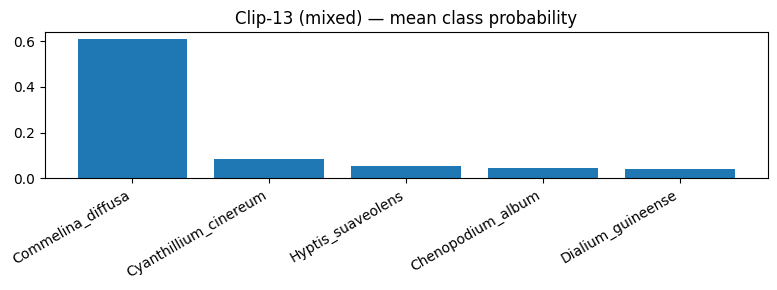

In [ ]:
clip13 = [p for p in video_paths if p.stem == 'VID_20260408_173405']
if clip13:
    cap=cv2.VideoCapture(str(clip13[0])); fps=cap.get(cv2.CAP_PROP_FPS) or 30; step=max(int(fps//3),1)
    probs=[]; idx=0
    tf=transforms.Compose([transforms.ToPILImage(),transforms.Resize((INPUT,INPUT)),
                           transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    cnn_flat.eval()
    with torch.no_grad():
        while True:
            ok,fr=cap.read()
            if not ok: break
            if idx%step==0:
                x=tf(cv2.cvtColor(clahe_enhance(fr),cv2.COLOR_BGR2RGB)).unsqueeze(0).to(DEVICE)
                probs.append(torch.softmax(cnn_flat(x),1).cpu().numpy()[0])
            idx+=1
    cap.release(); probs=np.array(probs); mean_p=probs.mean(0)
    top=np.argsort(mean_p)[::-1][:5]
    print("Clip-13 mean prediction distribution (top-5):")
    for t in top: print(f"  {species[t]:24s} {mean_p[t]:.3f}")
    print(f"Mean top-1 confidence: {probs.max(1).mean():.3f} (low => appropriate uncertainty on mixed scene)")
    plt.figure(figsize=(8,3)); plt.bar([species[t] for t in top],[mean_p[t] for t in top])
    plt.xticks(rotation=30,ha='right'); plt.title('Clip-13 (mixed) — mean class probability')
    plt.tight_layout(); plt.savefig(WORK/'fig_clip13_probe.png',dpi=150); plt.show()

## 13. Grad-CAM interpretability

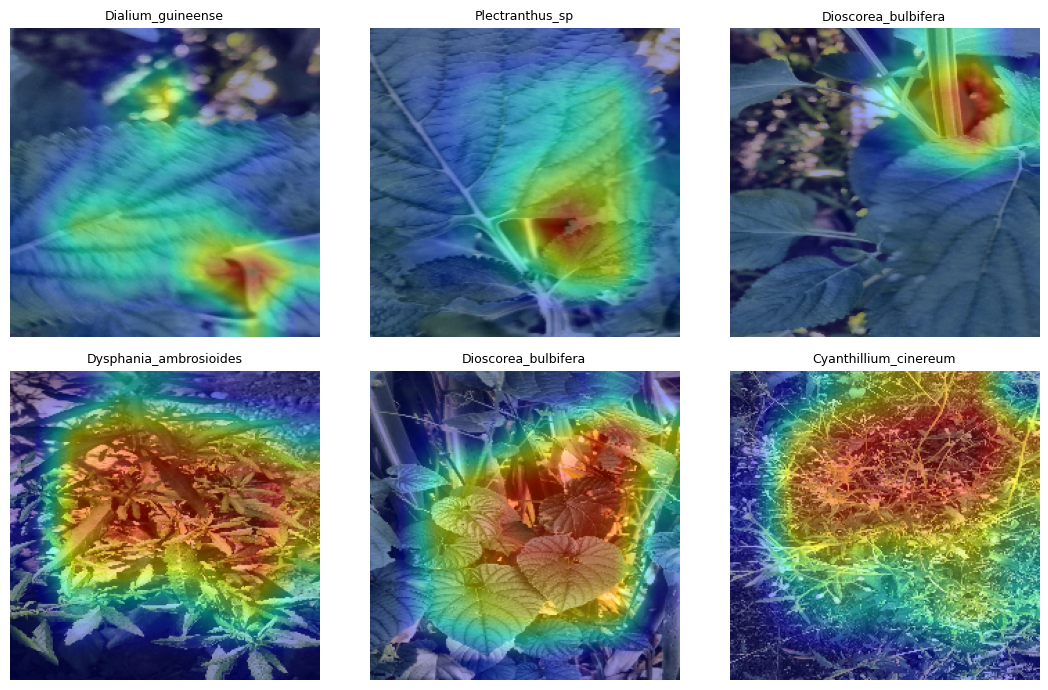

In [ ]:
import torch.nn.functional as F
class GradCAM:
    def __init__(s,model,layer):
        s.m=model.eval(); s.a=None; s.g=None
        layer.register_forward_hook(lambda mod,i,o: setattr(s,'a',o.detach()))
        layer.register_full_backward_hook(lambda mod,gi,go: setattr(s,'g',go[0].detach()))
    def __call__(s,x,c):
        out=s.m(x); out=out[0] if isinstance(out,tuple) else out
        s.m.zero_grad(); out[0,c].backward()
        w=s.g.mean((2,3),keepdim=True); cam=F.relu((w*s.a).sum(1)).squeeze().cpu().numpy()
        cam=cv2.resize(cam,(INPUT,INPUT)); return (cam-cam.min())/(cam.max()-cam.min()+1e-8)
cam=GradCAM(cnn_flat,target_layer)
tf=transforms.Compose([transforms.ToPILImage(),transforms.Resize((INPUT,INPUT)),
                       transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
s=split_grouped['test'].sample(min(6,len(split_grouped['test'])),random_state=0)
fig,ax=plt.subplots(2,3,figsize=(11,7))
for k,(_,r) in enumerate(s.iterrows()):
    rgb=cv2.cvtColor(clahe_enhance(cv2.imread(r['path'])),cv2.COLOR_BGR2RGB)
    x=tf(rgb).unsqueeze(0).to(DEVICE).requires_grad_(True)
    c=cnn_flat(x).argmax(1).item(); h=cam(x,c); base=cv2.resize(rgb,(INPUT,INPUT))
    heat=cv2.applyColorMap((h*255).astype(np.uint8),cv2.COLORMAP_JET)[:,:,::-1]
    ax[k//3,k%3].imshow((0.6*base+0.4*heat).astype(np.uint8)); ax[k//3,k%3].axis('off')
    ax[k//3,k%3].set_title(species[c],fontsize=9)
plt.tight_layout(); plt.savefig(WORK/'fig_gradcam.png',dpi=150); plt.show()

## 14. Results summary

In [ ]:
summary=pd.DataFrame([
 {'Model':'Handcrafted + RF','Protocol':'Grouped','Accuracy':round(hand_acc,3),'Macro-F1':round(hand_f1,3)},
 {'Model':'CNN flat','Protocol':'Grouped (honest)','Accuracy':round(flat_acc,3),'Macro-F1':round(flat_f1,3)},
 {'Model':'CNN two-tier','Protocol':'Grouped (honest)','Accuracy':round(tt_acc,3),'Macro-F1':round(tt_f1,3)},
 {'Model':'CNN flat','Protocol':'Naive (leaky)','Accuracy':round(naive_acc,3),'Macro-F1':float('nan')},
])
print(summary.to_string(index=False))
print(f"\nGrowth-form (4-way: herb/shrub/vine/tree) accuracy: {growth_acc:.3f}")
print(f"Leakage gap (naive - grouped): {naive_acc-flat_acc:+.3f}")
summary.to_csv(WORK/'results_summary.csv',index=False)
json.dump({'handcrafted':hand_acc,'cnn_flat_grouped':flat_acc,'cnn_twotier':tt_acc,
           'cnn_flat_naive':naive_acc,'growth_form_acc':growth_acc,
           'species':species,'n_species':len(species)},open(WORK/'metrics.json','w'),indent=2)
print('\nArtefacts:',[p.name for p in WORK.glob('fig_*.png')],'+ results_summary.csv, metrics.json')

           Model         Protocol  Accuracy  Macro-F1
Handcrafted + RF          Grouped     0.427     0.600
        CNN flat Grouped (honest)     0.532     0.624
    CNN two-tier Grouped (honest)     0.544     0.674
        CNN flat    Naive (leaky)     0.987       NaN

Growth-form (4-way: herb/shrub/vine/tree) accuracy: 0.629
Leakage gap (naive - grouped): +0.454

Artefacts: ['fig_confusion.png', 'fig_clahe.png', 'fig_gradcam.png', 'fig_clip13_probe.png'] + results_summary.csv, metrics.json


---
### Reproducibility & honest limitations
- Seeds fixed (42) across Python/NumPy/PyTorch; split grouped by `clip_id`.
- Only **3 of 17 species** have ≥2 clips, so cross-clip generalisation is
  directly tested for those; the other 14 use a temporal within-clip split and
  their accuracy is an optimistic-but-honest estimate. Collecting ≥2 clips per
  species would remove this caveat.
- Clip 13 excluded from train/test (admitted *Mimosa/Senna* mixture); reused
  only as a qualitative mixed-scene probe.
- The naive-vs-grouped gap quantifies the cost of frame leakage and is the
  headline methodological result.